[[ 69.   1. 160. ...   1.   1.   0.]
 [ 69.   0. 140. ...   0.   2.   0.]
 [ 66.   0. 150. ...   2.   0.   0.]
 ...
 [ 35.   1. 120. ...   1.   0.   2.]
 [ 35.   0. 138. ...   0.   0.   0.]
 [ 35.   1. 126. ...   0.   0.   2.]]
[0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 1
 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1
 1 1 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0
 1]
[[9.25378173e+29 2.71828183e+00 3.06984964e+69 ... 2.71828183e+00
  2.71828183e+00 1.00000000e+00]
 [9.25378173e+29 1.00000000e+00 6.32743171e+60 ... 1.00000000e+00
  7

Text(0.5, 0, 'normalized age values')

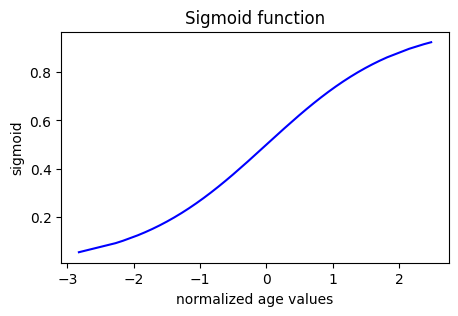

In [309]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, math


data_in=pd.read_csv("/Users/varad/Downloads/heart_cleveland_upload.csv")
x_train = data_in[['age','sex','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']].values
y_train= data_in['condition'].values

print(x_train)
print(y_train)

expo=np.exp(x_train)
print(expo)


#WE HAVE CREATED THE SIGMOID FUNCTION TO VISUALISE THE GRAPH USING 1 FEATURE BUT IN THE ACTUAL PROGRAM WE USE 2 FEATURES.
age=data_in['age'].values
def sigmoid(z):
    g=1/(1+np.exp(-z))
    return g

def z_score(age):
    mean=np.mean(age)
    sigma=np.std(age)
    z = (age - mean) / sigma 

    return z

##we use sort function to sort the values to get a smooth curve of the sigmoid function.

fig,ax = plt.subplots(1,1,figsize=(5,3))
z=z_score(age)
z_sorted=np.sort(z)
sig=sigmoid(z_sorted)
ax.plot(z_sorted, sig, c="b")
ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid')
ax.set_xlabel('normalized age values')


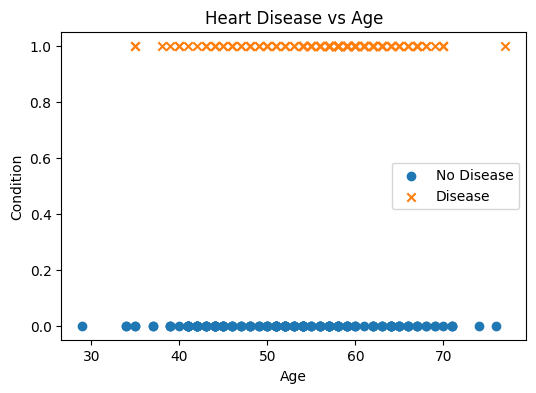

In [310]:
plt.figure(figsize=(6,4))

# Condition = 0 (No disease)
plt.scatter(x_train[y_train == 0, 0],y_train[y_train == 0],marker='o',label='No Disease')

# Condition = 1 (Disease)
plt.scatter(x_train[y_train == 1, 0],y_train[y_train == 1],marker='x',label='Disease')

plt.xlabel("Age")
plt.ylabel("Condition")
plt.title("Heart Disease vs Age")
plt.legend()
plt.show()

In [311]:
#lambda here is to regularize the function to stop overftting.
def compute_cost(x,y,w,b,lambda_):
    m=x.shape[0]
    n=x.shape[1]
    cost=0.0
    for i in range(m):
        z_intial=np.dot(x[i],w)+b
        f_wb=sigmoid(z_intial)
        cost+= -(y[i]*np.log(f_wb)+(1-y[i])*np.log(1 - f_wb))
    cost = cost/m
#for regularised cost function
    reg_cost=0
    for j in range(n):
        reg_cost+=w[j]**2
    reg_cost= (lambda_/(2*m))* reg_cost

    total_cost=cost + reg_cost

    return total_cost

def compute_gradient(x,y,w,b,lambda_):
    m,n=x.shape
    dw=np.zeros(n)
    db=0.0

    for i in range(m):
        z=np.dot(x[i],w) + b
        f_w=sigmoid(z)
        err= f_w - y[i]
        
        for j in range(n):
            dw[j] = dw[j] + err * x[i,j]
        db= db + err
    #now we regularise
    for k in range(n):
        dw[k]=dw[k] + (lambda_/m) * w[k]

    dw=dw/m
    db= db/m

    return dw,db

def gradient_desc(x,y,w_in,b_in,alpha,num_iters,lambda_):
    w=copy.deepcopy(w_in)
    b=b_in
    #we make a copy of the array into a whole new array so that w_in remains unchanged outside the function and for b_in its just a number and its immutable.

    hist=[]
    for i in range(num_iters):
        dw,db=compute_gradient(x,y,w,b,lambda_)

        w = w - alpha * dw               
        b = b - alpha * db 

        if i < 100000:
            hist.append(compute_cost(x,y,w,b,lambda_))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {hist[-1]}   ")

    return w,b,hist
        
def z_score_norm(x):
    mu=np.mean(x,axis=0)
    sigma=np.std(x,axis=0)

    x_final=(x-mu)/sigma
    return x_final,mu,sigma

In [312]:
w_in=np.zeros(x_train.shape[1])
b_in=0.0
alpha=0.3
iters=1000
lambda_=1
x_norm,mu,sigma=z_score_norm(x_train)

w_out,b_out,history=gradient_desc(x_norm,y_train,w_in,b_in,alpha,iters,lambda_)
print(f"updated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.6044506080290631   
Iteration  100: Cost 0.36602000858369244   
Iteration  200: Cost 0.36539250486357366   
Iteration  300: Cost 0.365501019341414   
Iteration  400: Cost 0.3655752608005305   
Iteration  500: Cost 0.3656071567395388   
Iteration  600: Cost 0.36561962547231647   
Iteration  700: Cost 0.3656243656348135   
Iteration  800: Cost 0.36562615258764464   
Iteration  900: Cost 0.36562682486676684   
updated parameters: w:[-0.17637671  0.52410999  0.35113709  0.260603   -0.36612224  0.2308286
 -0.58778152  0.56275013  0.25007035  0.33164856  1.22345773  0.75931201], b:-0.09138176181048127


In [315]:
def predict(x,w,b):
    prob=sigmoid(np.dot(w,x)+b)

    if prob>=0.5:
        return 1
    else:
        return 0

correct=0
for i in range(len(y_train)):
    pred=predict(x_norm[i],w_out,b_out)
#matches the prediction with the condition.
    if pred==y_train[i]:
        correct+=1
#checks the accuracy of the code
accuracy=(correct/len(y_train))*100
print(f"Accuracy: {accuracy:.2f}%")

user_data = np.array([
    float(input("Age: ")),
    float(input("Sex (0=female,1=male): ")),
    float(input("Resting Blood Pressure: ")),
    float(input("Cholesterol: ")),
    float(input("Fasting Blood Sugar: ")),
    float(input("Rest ECG: ")),
    float(input("Max Heart Rate: ")),
    float(input("Exercise Induced Angina: ")),
    float(input("Oldpeak: ")),
    float(input("Slope: ")),
    float(input("CA: ")),
    float(input("Thal: "))
])

user_norm=(user_data - mu)/sigma
prediction=predict(user_norm,w_out,b_out)
if prediction==0:
    print("NO HEART ATTACK")
else:
    print("HEART ATTACK!")
      

Accuracy: 84.85%


Age:  50
Sex (0=female,1=male):  1
Resting Blood Pressure:  125
Cholesterol:  230
Fasting Blood Sugar:  400
Rest ECG:  220
Max Heart Rate:  140
Exercise Induced Angina:  2
Oldpeak:  140
Slope:  1
CA:  2
Thal:  1


NO HEART ATTACK
